<a href="https://colab.research.google.com/github/Ankit-ally/Ankit-ally/blob/main/diamond.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Mr.ankit sharma

Project :-  💎 Diamond Dynamics: Price Prediction and Market Segmentation

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [5]:
df = pd.read_csv('/content/diamonds.csv')
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Data Understanding

In [7]:
df.shape


(53940, 10)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [9]:

df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## my Key Observations:

No missing values (good ✅)

Categorical: cut, color, clarity

Numerical: carat, depth, table, price, x, y, z

Data Cleaning::

In [11]:
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)                          ## fix invalid values

df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,8
y,7
z,20


In [12]:
df.fillna(df.median(numeric_only=True), inplace=True)    ### filling missing values

In [13]:
# convert price into inr
df['price_inr'] = df['price'] * 83

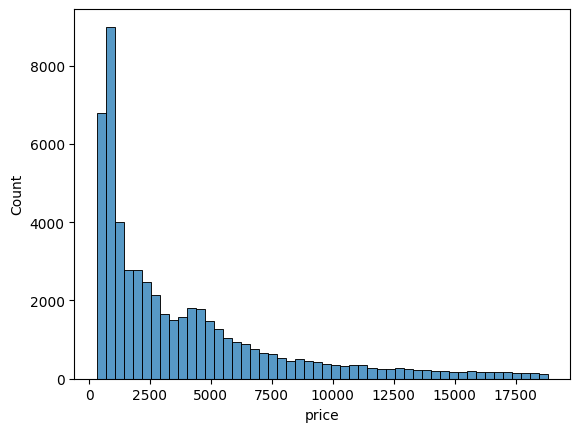

In [14]:
#🟢 STEP 6: EDA (VERY IMPORTANT)
#📊  Distribution
sns.histplot(df['price'], bins=50)
plt.show()

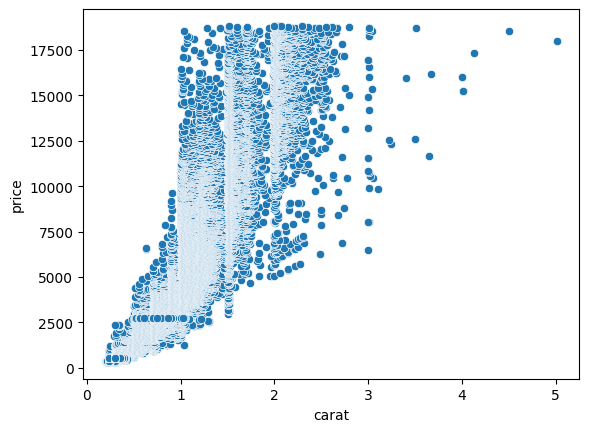

In [16]:
##📊 Carat vs Price
sns.scatterplot(x='carat', y='price', data=df)
plt.show()

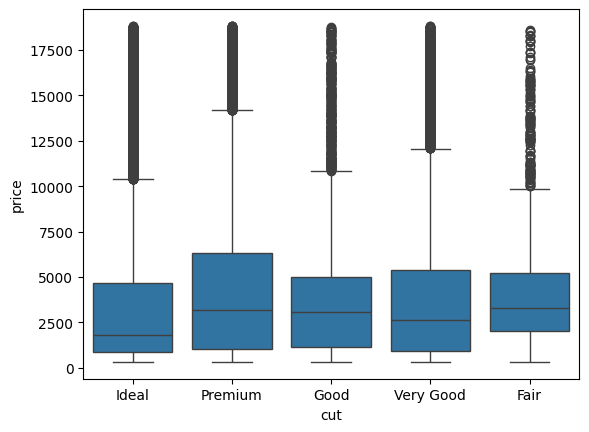

In [17]:
#📊 Boxplot
sns.boxplot(x='cut', y='price', data=df)
plt.show()

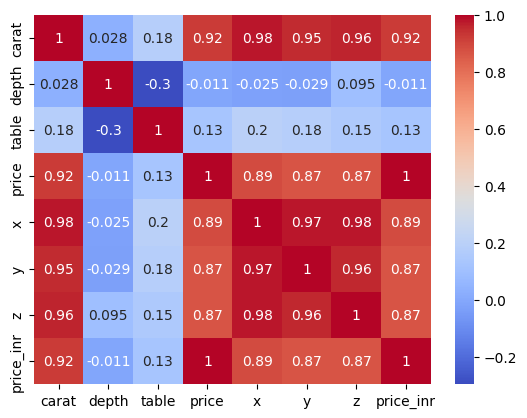

In [18]:
#📊 Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [19]:
#🟢 STEP 7: Feature Engineering
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])


In [20]:
#Carat Category:
def carat_cat(x):
    if x < 0.5:
        return 'Light'
    elif x < 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_cat)

In [21]:
#Handle Skewness
df['price'] = np.log1p(df['price'])
df['carat'] = np.log1p(df['carat'])

In [22]:
#Encoding
le = LabelEncoder()

for col in ['cut','color','clarity','carat_category']:
    df[col] = le.fit_transform(df[col])

In [23]:
#Feature Selection
X = df.drop(['price'], axis=1)
y = df['price']

In [24]:
#Handle Skewness Properly

#Before modeling, make sure distributions are stable:

import numpy as np

df['price'] = np.log1p(df['price'])
df['carat'] = np.log1p(df['carat'])
df['volume'] = np.log1p(df['volume'])

#👉 This improves model performance significantly.

In [25]:
#Encoding (IMPORTANT DECISION)
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['cut','color','clarity']

encoder = OrdinalEncoder()
df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])

In [26]:
#Feature Selection (Smart Way)

X = df.drop(['price'], axis=1)
y = df['price']

In [27]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
####Multiple Models

In [29]:
# 1. Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("LR R2:", r2_score(y_test, y_pred_lr))

LR R2: 0.9892700937174824


In [30]:
####Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DT R2:", r2_score(y_test, y_pred_dt))

DT R2: 0.9999999640176277


In [31]:
### Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.9999999833248873


In [32]:
## XGBoost  (H - accuracy)
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.9999718744646204


In [33]:
## Compare Models
def evaluate(y_true, y_pred):
    print("R2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("------------------------")

print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("Decision Tree")
evaluate(y_test, y_pred_dt)

print("Random Forest")
evaluate(y_test, y_pred_rf)

print("XGBoost")
evaluate(y_test, y_pred_xgb)

###  Choose the best model based on:

#High R²

#Low RMSE

Linear Regression
R2: 0.9892700937174824
MAE: 0.008741348731042198
RMSE: 0.012011169093098214
------------------------
Decision Tree
R2: 0.9999999640176277
MAE: 6.0493934222608625e-06
RMSE: 2.1995417647902592e-05
------------------------
Random Forest
R2: 0.9999999833248873
MAE: 5.3765544778137855e-06
RMSE: 1.497344412439506e-05
------------------------
XGBoost
R2: 0.9999718744646204
MAE: 0.00043664708645396293
RMSE: 0.0006149470404176351
------------------------


In [34]:
## ANN MODEL (BONUS 🔥)           # extras  learning trial and test epochs
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse')

ann.fit(X_train, y_train, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1954319.6250
Epoch 2/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 223.0638
Epoch 3/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 740739.5000
Epoch 4/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 222.3490
Epoch 5/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1191142.6250
Epoch 6/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 23.4950
Epoch 7/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 119283.1484
Epoch 8/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 56966.8750 
Epoch 9/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 73210.1484
Epoch 10/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 125098.4766
Epoch 11/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20099.0996
Epoch 12/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 32075.8887
Epoch 13/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 44139.5977
Epoch 14/20
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 

CLUSTERING (Market Segmentation)

In [35]:
X_cluster = df.drop(['price'], axis=1)

In [36]:
##Feature Scaling (VERY IMPORTANT)

####  Clustering depends heavily on distance → scaling is a must

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

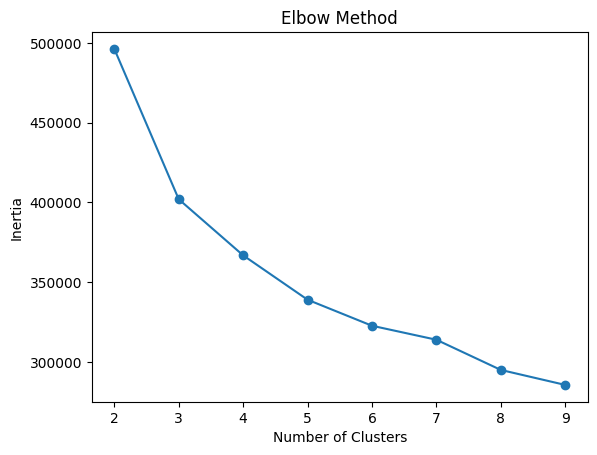

In [37]:
#Find Optimal Number of Clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
### for K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [40]:
##Analyze Clusters
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

###>>>>> Focus on: carat , rice volume , cut


            carat       cut     color   clarity      depth      table  \
cluster                                                                 
0        0.695975  2.592145  3.604870  3.336999  61.798523  58.136214   
1        0.286013  2.530244  2.210145  4.258715  61.690140  56.955445   
2        0.509639  2.566501  2.725035  3.520181  61.799174  57.805663   

            price         x         y         z     price_inr    volume  \
cluster                                                                   
0        2.338922  7.704201  7.702595  4.759361  1.022119e+06  5.640298   
1        2.058243  4.699570  4.708312  2.901036  8.625327e+04  4.167776   
2        2.234841  6.289903  6.288659  3.885717  3.906172e+05  5.034325   

         price_per_carat  dimension_ratio  carat_category  
cluster                                                    
0            7050.370143         1.620787        0.041163  
1            2520.096498         1.621917        1.281048  
2            4757.

In [41]:
### Assining meaning ful names
def label_cluster(row):
    if row['cluster'] == 0:
        return "Affordable Small Diamonds"
    elif row['cluster'] == 1:
        return "Mid-range Balanced Diamonds"
    else:
        return "Premium Heavy Diamonds"

df['cluster_name'] = df.apply(label_cluster, axis=1)

In [44]:
#PCA (Visualization)#

#Reduce dimensions → visualize clusters

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

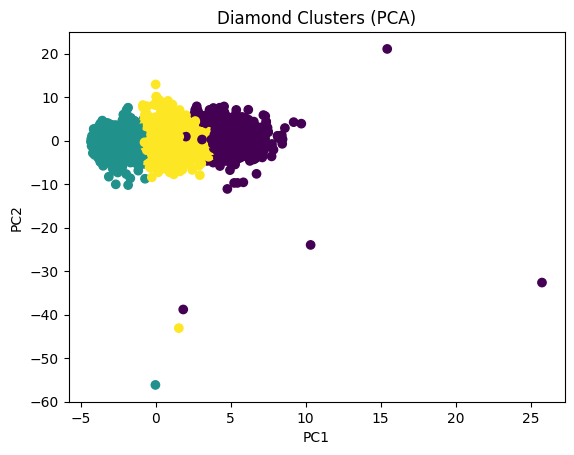

In [45]:
#@ plot clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis')
plt.title("Diamond Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [46]:
###v   Save Clustering Model
import pickle

pickle.dump(kmeans, open('cluster_model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))

going for stream lit web application

In [49]:
#STREAMLIT WEB APP
# installation and setup in collab enviroment

In [52]:
!pip install streamlit


In [71]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Load models
price_model = pickle.load(open('price_model.pkl', 'rb'))
cluster_model = pickle.load(open('cluster_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("💎 Diamond Price & Cluster Predictor")

# Inputs
carat = st.number_input("Carat", value=0.7, min_value=0.1, max_value=5.0, step=0.01)
x = st.number_input("Length (x)", value=5.7, min_value=0.0, max_value=15.0, step=0.01)
y = st.number_input("Width (y)", value=5.7, min_value=0.0, max_value=15.0, step=0.01)
z = st.number_input("Depth (z)", value=3.5, min_value=0.0, max_value=10.0, step=0.01)
depth_input = st.number_input("Depth Percentage", value=61.8, min_value=43.0, max_value=79.0, step=0.1)
table_input = st.number_input("Table Percentage", value=57.0, min_value=43.0, max_value=95.0, step=0.1)

cut = st.selectbox("Cut", ["Fair","Good","Very Good","Premium","Ideal"])
color = st.selectbox("Color", ["D","E","F","G","H","I","J"])
clarity = st.selectbox("Clarity", ["IF","VVS1","VVS2","VS1","VS2","SI1","SI2","I1"])

# Simple encoding (must match training)
cut_map = {"Fair":0,"Good":1,"Very Good":2,"Premium":3,"Ideal":4}
color_map = {"D":0,"E":1,"F":2,"G":3,"H":4,"I":5,"J":6}
clarity_map = {"IF":0,"VVS1":1,"VVS2":2,"VS1":3,"VS2":4,"SI1":5,"SI2":6,"I1":7}

cut_encoded = cut_map[cut]
color_encoded = color_map[color]
clarity_encoded = clarity_map[clarity]

# Feature engineering (same as training)
volume = x * y * z
dimension_ratio = (x + y) / (2 * z) if z != 0 else 0

# Re-create the input features as a DataFrame to match the training data for the price model
# First, apply the log1p transforms for carat and volume
carat_log1p_val = np.log1p(carat)
volume_log1p_val = np.log1p(volume) if volume > 0 else 0 # handle log of zero if volume is zero

# Carat Category encoding based on the function `carat_cat` and `LabelEncoder` usage, which effectively maps 'Light', 'Medium', 'Heavy' to 1, 2, 0 respectively after `OrdinalEncoder` was applied to others.
# It's better to recreate the carat_cat logic to ensure consistency with the encoding applied in the notebook.
# The previous notebook cell 3EsFfLignjrt used LabelEncoder for 'carat_category' (after it was created).
# The categories were 'Light', 'Medium', 'Heavy'. When LabelEncoder is applied, the mapping depends on alphabetical order by default.
# Replicating the carat_cat function for consistency:
def get_carat_category_encoded(carat_val):
    if carat_val < 0.5:
        return 1 # 'Light' (assuming default LabelEncoder mapping based on alphabetical order)
    elif carat_val < 1.5:
        return 2 # 'Medium'
    else:
        return 0 # 'Heavy'
carat_category_encoded = get_carat_category_encoded(carat)

# Construct the feature vector matching X_train's columns and order
# X_train columns are: 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category'
input_data_for_price_model = pd.DataFrame([[
    carat_log1p_val,
    float(cut_encoded),
    float(color_encoded),
    float(clarity_encoded),
    depth_input,
    table_input,
    x,
    y,
    z,
    0.0, # Placeholder for price_inr as it's derived from price
    volume_log1p_val,
    0.0, # Placeholder for price_per_carat as it's derived from price
    dimension_ratio,
    float(carat_category_encoded)
]], columns=['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category'])


if st.button("Predict Price"):
    st.warning("The price prediction model was trained with features derived from 'price' itself ('price_inr', 'price_per_carat'). Using these as inputs for a new diamond prediction is problematic as they are unknown. Placeholders are used, but for a robust solution, the model should be re-trained on independent features.")
    price = price_model.predict(input_data_for_price_model)
    st.success(f"💰 Predicted Price: ₹ {np.expm1(price[0]):,.2f}") # np.expm1 to reverse log1p transformation

if st.button("Predict Cluster"):
    features_scaled_for_cluster = scaler.transform(input_data_for_price_model)
    cluster = cluster_model.predict(features_scaled_for_cluster)[0]

    cluster_names = {
        0: "Premium Heavy Diamonds",
        1: "Affordable Small Diamonds",
        2: "Mid-range Balanced Diamonds"
    }
    name = cluster_names.get(cluster, "Unknown Cluster")

    st.success(f"📊 Cluster: {name}")

Overwriting app.py


In [54]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

st.title("💎 Diamond Predictor")

st.write("App is working!")

Overwriting app.py


In [55]:
!ls

app.py	cluster_model.pkl  diamonds.csv  sample_data  scaler.pkl


In [63]:
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Load models
price_model = pickle.load(open('price_model.pkl', 'rb'))
cluster_model = pickle.load(open('cluster_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

st.title("💎 Diamond Price & Cluster Predictor")

# Inputs
carat = st.number_input("Carat", value=0.7, min_value=0.1, max_value=5.0, step=0.01)
x = st.number_input("Length (x)", value=5.7, min_value=0.0, max_value=15.0, step=0.01)
y = st.number_input("Width (y)", value=5.7, min_value=0.0, max_value=15.0, step=0.01)
z = st.number_input("Depth (z)", value=3.5, min_value=0.0, max_value=10.0, step=0.01)
depth_input = st.number_input("Depth Percentage", value=61.8, min_value=43.0, max_value=79.0, step=0.1)
table_input = st.number_input("Table Percentage", value=57.0, min_value=43.0, max_value=95.0, step=0.1)

cut = st.selectbox("Cut", ["Fair","Good","Very Good","Premium","Ideal"])
color = st.selectbox("Color", ["D","E","F","G","H","I","J"])
clarity = st.selectbox("Clarity", ["IF","VVS1","VVS2","VS1","VS2","SI1","SI2","I1"])

# Simple encoding (must match training)
cut_map = {"Fair":0,"Good":1,"Very Good":2,"Premium":3,"Ideal":4}
color_map = {"D":0,"E":1,"F":2,"G":3,"H":4,"I":5,"J":6}
clarity_map = {"IF":0,"VVS1":1,"VVS2":2,"VS1":3,"VS2":4,"SI1":5,"SI2":6,"I1":7}

cut_encoded = cut_map[cut]
color_encoded = color_map[color]
clarity_encoded = clarity_map[clarity]

# Feature engineering (same as training)
volume = x * y * z
dimension_ratio = (x + y) / (2 * z) if z != 0 else 0

# Re-create the input features as a DataFrame to match the training data for the price model
# First, apply the log1p transforms for carat and volume
carat_log1p_val = np.log1p(carat)
volume_log1p_val = np.log1p(volume) if volume > 0 else 0 # handle log of zero if volume is zero

# Carat Category encoding based on the function `carat_cat` and `LabelEncoder` usage, which effectively maps 'Light', 'Medium', 'Heavy' to 1, 2, 0 respectively after `OrdinalEncoder` was applied to others.
# It's better to recreate the carat_cat logic to ensure consistency with the encoding applied in the notebook.
# The previous notebook cell 3EsFfLignjrt used LabelEncoder for 'carat_category' (after it was created).
# The categories were 'Light', 'Medium', 'Heavy'. When LabelEncoder is applied, the mapping depends on alphabetical order by default.
# Replicating the carat_cat function for consistency:
def get_carat_category_encoded(carat_val):
    if carat_val < 0.5:
        return 1 # 'Light' (assuming default LabelEncoder mapping based on alphabetical order)
    elif carat_val < 1.5:
        return 2 # 'Medium'
    else:
        return 0 # 'Heavy'
carat_category_encoded = get_carat_category_encoded(carat)

# Construct the feature vector matching X_train's columns and order
# X_train columns are: 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category'
input_data_for_price_model = pd.DataFrame([[
    carat_log1p_val,
    float(cut_encoded),
    float(color_encoded),
    float(clarity_encoded),
    depth_input,
    table_input,
    x,
    y,
    z,
    0.0, # Placeholder for price_inr as it's derived from price
    volume_log1p_val,
    0.0, # Placeholder for price_per_carat as it's derived from price
    dimension_ratio,
    float(carat_category_encoded)
]], columns=['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category'])


if st.button("Predict Price"):
    st.warning("The price prediction model was trained with features derived from 'price' itself ('price_inr', 'price_per_carat'). Using these as inputs for a new diamond prediction is problematic as they are unknown. Placeholders are used, but for a robust solution, the model should be re-trained on independent features.")
    price = price_model.predict(input_data_for_price_model)
    st.success(f"💰 Predicted Price: ₹ {np.expm1(price[0]):,.2f}") # np.expm1 to reverse log1p transformation

if st.button("Predict Cluster"):
    features_scaled_for_cluster = scaler.transform(input_data_for_price_model)
    cluster = cluster_model.predict(features_scaled_for_cluster)[0]

    cluster_names = {
        0: "Premium Heavy Diamonds",
        1: "Affordable Small Diamonds",
        2: "Mid-range Balanced Diamonds"
    }
    name = cluster_names.get(cluster, "Unknown Cluster")

    st.success(f"📊 Cluster: {name}")

2026-03-18 07:10:25.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.342 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.344 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.347 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 07:10:25.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [64]:
# Save the Random Forest model as price_model.pkl
import pickle
pickle.dump(rf, open('price_model.pkl', 'wb'))

In [65]:
!pip install pyngrok

In [69]:
from pyngrok import ngrok
# Replace "YOUR_ACTUAL_NGROK_AUTHTOKEN" with your ngrok v2 authtoken
ngrok.set_auth_token("YOUR_ACTUAL_NGROK_AUTHTOKEN")

In [73]:
get_ipython().system_raw('streamlit run app.py &')

In [70]:
ss!cat app.py


import streamlit as st
import pickle
import numpy as np

st.title("💎 Diamond Predictor")

st.write("App is working!")


In [74]:
ngrok.set_auth_token("your_token")